# Inspect coregister.add_ndwi_mask output

End-to-end visual sanity check of `sat_tile_stack.coregister.add_ndwi_mask` on a single lake.

Pick one input lake `.nc`, the year-matching NDWI zarr, run the co-registration, then plot:

1. RGB strip vs NDWI-mask strip across selected timesteps (visual co-registration check).
2. NDWI water-pixel count per day vs `water_area` (if present).
3. NDWI vs existing in-stack `mask` band on the same day (different things, but cross-check coverage).

Run this once per workflow change; if it looks right on a handful of lakes, batch on Sherlock.

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sat_tile_stack.coregister import add_ndwi_mask

# --- Configure ---
INPUT_NC  = Path('../../lake-vision/datasets/imgseqs/tstack_CW2019_1579.nc')
ZARR_PATH = Path('../../essd/masking/josh_ndwi_masks/lake_detection_binary_masks_2019.zarr')
OUTPUT_NC = Path('/tmp/tstack_CW2019_1579_with_ndwi.nc')

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})

## 1. Run the co-registration

In [2]:
summary = add_ndwi_mask(INPUT_NC, ZARR_PATH, OUTPUT_NC)
summary

{'input': '../../lake-vision/datasets/imgseqs/tstack_CW2019_1579.nc',
 'output': '/tmp/tstack_CW2019_1579_with_ndwi.nc',
 'n_time': 153,
 'n_days_matched': 134,
 'n_pixels_water': 63952,
 'bbox_3413': (-182995.6880557996,
  -2304162.598924408,
  -177155.52239107643,
  -2298322.4335321295)}

In [3]:
ds_in  = xr.open_dataset(INPUT_NC)
ds_out = xr.open_dataset(OUTPUT_NC)

print('Input  reflectance:', ds_in.reflectance.shape)
print('Output reflectance:', ds_out.reflectance.shape)
print('Input  bands :', ds_in.attrs.get('band'))
print('Output bands :', ds_out.attrs.get('band'))

band_names = ds_out.attrs.get('band')
B_RED  = band_names.index('B04')
B_GRN  = band_names.index('B03')
B_BLU  = band_names.index('B02')
B_MASK = band_names.index('mask')
B_NDWI = band_names.index('ndwi_mask')
print(f'\nBand indices: red={B_RED}, green={B_GRN}, blue={B_BLU}, mask={B_MASK}, ndwi={B_NDWI}')

Input  reflectance: (153, 8, 512, 512)
Output reflectance: (153, 9, 512, 512)
Input  bands : ['B04', 'B03', 'B02', 'B08', 'B11', 'B12', 'cloudmask', 'mask']
Output bands : ['B04', 'B03', 'B02', 'B08', 'B11', 'B12', 'cloudmask', 'mask', 'ndwi_mask']

Band indices: red=0, green=1, blue=2, mask=7, ndwi=8


## 2. Full dataset structure

Drops the entire `ds_out` repr, file size, per-variable + per-coord summaries, per-band metadata as a tidy table, and global attrs.

In [4]:
# Full xarray repr
print(ds_out)

# File size on disk
size_in  = INPUT_NC.stat().st_size  / 1024**2
size_out = OUTPUT_NC.stat().st_size / 1024**2
print(f'\nFile size: input {size_in:.1f} MB \u2192 output {size_out:.1f} MB ({size_out - size_in:+.1f} MB)')

# Per-data-variable summary
print('\nData variables:')
for name, var in ds_out.data_vars.items():
    n_mb = var.nbytes / 1024**2
    print(f'  {name:24s}  dims={var.dims}  shape={tuple(var.shape)}  dtype={var.dtype}  in-memory={n_mb:.1f} MB')

# Per-coord summary
print('\nCoordinates:')
for name, var in ds_out.coords.items():
    sample = var.values
    if sample.ndim == 0:
        sample_repr = repr(sample.item())
    elif len(sample) <= 4:
        sample_repr = repr(sample.tolist())
    else:
        sample_repr = f'[{sample[0]!r}, {sample[1]!r}, ..., {sample[-1]!r}]'
    print(f'  {name:24s}  dims={var.dims}  shape={tuple(var.shape)}  dtype={var.dtype}  {sample_repr}')

# Per-band metadata table
import pandas as pd
band_attr = ds_out.attrs.get('band', [None] * ds_out.sizes['band'])
band_df = pd.DataFrame({
    'idx': ds_out.band.values,
    'name': band_attr,
    'common_name': ds_out.common_name.values,
    'title': ds_out.title.values,
    'gsd': ds_out.gsd.values,
    'center_wavelength': ds_out.center_wavelength.values,
})
print('\nPer-band metadata:')
print(band_df.to_string(index=False))

# Global attrs (one line each, truncated)
print('\nGlobal attrs:')
for k, v in ds_out.attrs.items():
    s = str(v).replace('\n', ' ')
    if len(s) > 100:
        s = s[:97] + '...'
    print(f'  {k}: {s}')

<xarray.Dataset> Size: 1GB
Dimensions:              (time: 153, band: 9, y: 512, x: 512)
Coordinates: (12/15)
  * time                 (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    eo_cloud_cover       (time) float64 1kB ...
    pct_nans             (time) float64 1kB ...
    pctnanpix_inmask     (time) float64 1kB ...
    pctcloudypix_inmask  (time) float64 1kB ...
    gsd                  (band) float64 72B ...
    ...                   ...
    full_width_half_max  (band) float64 72B ...
  * y                    (y) float64 4kB 7.649e+06 7.649e+06 ... 7.644e+06
  * x                    (x) float64 4kB 5.587e+05 5.587e+05 ... 5.638e+05
    constellation        <U10 40B ...
    instruments          <U3 12B ...
    epsg                 int64 8B ...
Dimensions without coordinates: band
Data variables:
    reflectance          (time, band, y, x) float32 1GB ...
    crs                  int32 4B ...
Attributes: (12/17)
    crs:                                      epsg:32622
    

## 3. Verify existing bands are bit-exactly preserved

In [5]:
old = ds_in.reflectance.values
new = ds_out.reflectance.isel(band=slice(0, old.shape[1])).values
print('Bands 0..n-1 unchanged:', np.array_equal(old, new, equal_nan=True))

Bands 0..n-1 unchanged: True


## 4. RGB strip vs NDWI-mask strip across the season

Pick a handful of timesteps (default: 8 evenly spaced days that have NDWI coverage).
Top row: RGB. Middle row: NDWI mask (binary). Bottom row: NDWI overlaid on RGB in cyan.
If the masks are co-registered correctly, water highlights should sit on top of the actual lake/water surface in the RGB.

In [6]:
ndwi_cube = ds_out.reflectance.isel(band=B_NDWI).values  # (time, y, x) float32
ndwi_per_day = (ndwi_cube > 0).sum(axis=(1, 2))
covered = np.where(ndwi_per_day > 0)[0]
if len(covered) >= 8:
    pick = covered[np.linspace(0, len(covered) - 1, 8).astype(int)]
else:
    pick = covered
print('Selected timesteps:', pick)
print('Dates:', [str(ds_out.time.values[i].astype('datetime64[D]')) for i in pick])
print('Water-pixel counts:', [int(ndwi_per_day[i]) for i in pick])

Selected timesteps: [  5  20  29  41  63  74  93 128]
Dates: ['2019-05-06', '2019-05-21', '2019-05-30', '2019-06-11', '2019-07-03', '2019-07-14', '2019-08-02', '2019-09-06']
Water-pixel counts: [1501, 7936, 1043, 749, 23, 38, 185, 1]


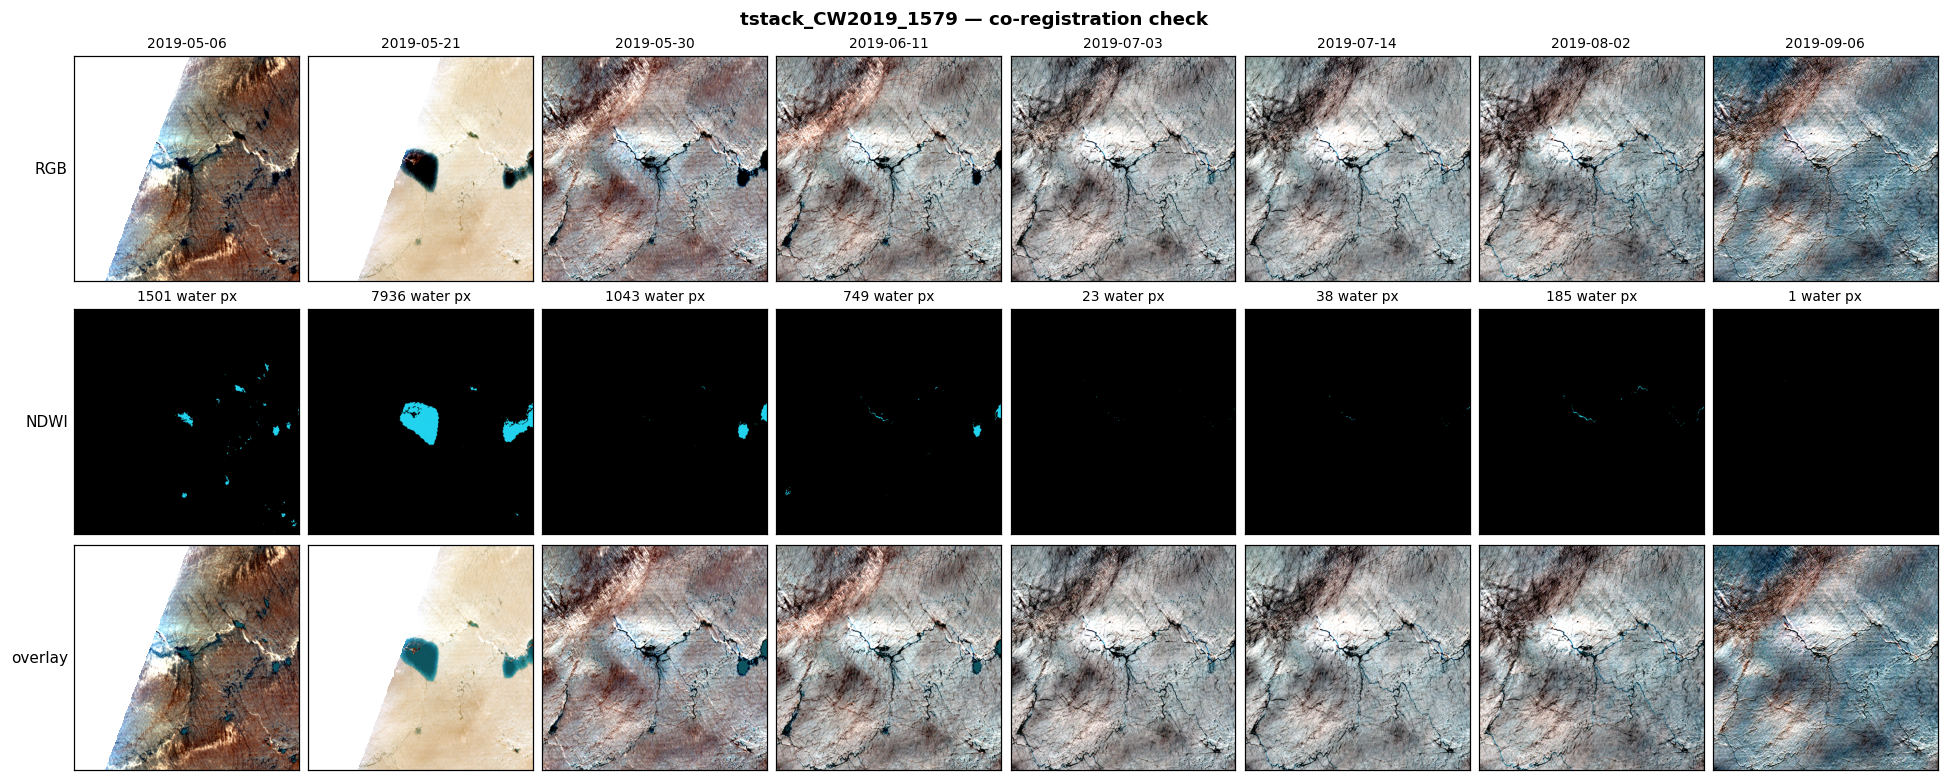

In [7]:
def stretch_rgb(rgb, p_low=2, p_high=98):
    out = np.zeros_like(rgb, dtype=np.float32)
    for c in range(3):
        chan = rgb[..., c].astype(np.float32)
        finite = chan[np.isfinite(chan)]
        if finite.size == 0:
            continue
        lo, hi = np.percentile(finite, [p_low, p_high])
        if hi - lo < 1e-9:
            continue
        out[..., c] = np.clip((chan - lo) / (hi - lo), 0, 1)
    return out

n = len(pick)
fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 7.0), constrained_layout=True)
if n == 1:
    axes = axes[:, None]

ndwi_cmap = ListedColormap(['#000000', '#22d3ee'])

for col, t_idx in enumerate(pick):
    rgb = np.stack([
        ds_out.reflectance.isel(time=t_idx, band=B_RED).values,
        ds_out.reflectance.isel(time=t_idx, band=B_GRN).values,
        ds_out.reflectance.isel(time=t_idx, band=B_BLU).values,
    ], axis=-1)
    rgb_s = stretch_rgb(rgb)
    ndwi  = ndwi_cube[t_idx]
    date  = str(ds_out.time.values[t_idx].astype('datetime64[D]'))

    axes[0, col].imshow(rgb_s)
    axes[0, col].set_title(date, fontsize=9)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    axes[1, col].imshow(ndwi, cmap=ndwi_cmap, vmin=0, vmax=1)
    axes[1, col].set_title(f'{int((ndwi>0).sum())} water px', fontsize=9)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

    overlay = rgb_s.copy()
    m = ndwi > 0
    overlay[m] = 0.6 * overlay[m] + 0.4 * np.array([0.13, 0.83, 0.93])
    axes[2, col].imshow(overlay)
    axes[2, col].set_xticks([]); axes[2, col].set_yticks([])

axes[0, 0].set_ylabel('RGB',     fontsize=10, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('NDWI',    fontsize=10, rotation=0, ha='right', va='center')
axes[2, 0].set_ylabel('overlay', fontsize=10, rotation=0, ha='right', va='center')
fig.suptitle(f'{INPUT_NC.stem} — co-registration check', fontsize=12, fontweight='bold')
plt.show()

## 5. Per-day NDWI water-pixel count vs `water_area` (if present)

These should be correlated but not equal — `water_area` is from Dunmire et al.'s `p_water` model,
while NDWI is a thresholded ratio of B03/B08.

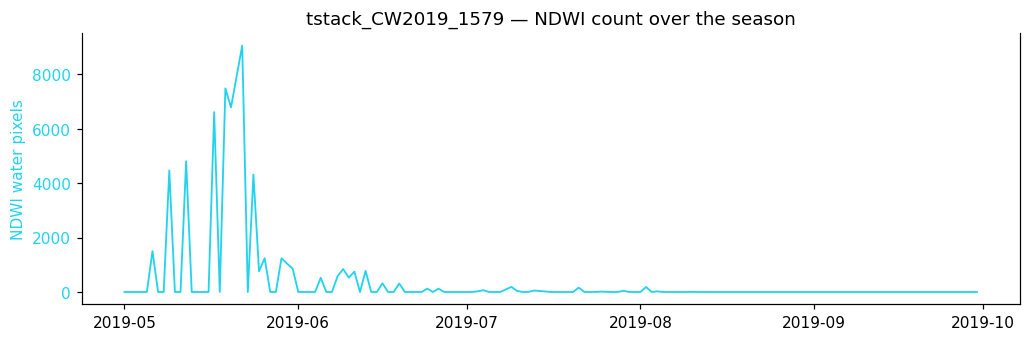

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(ds_out.time.values, ndwi_per_day, lw=1.2, color='#22d3ee', label='NDWI water px (count)')
ax.set_ylabel('NDWI water pixels', color='#22d3ee')
ax.tick_params(axis='y', labelcolor='#22d3ee')
ax.spines['top'].set_visible(False)

if 'water_area' in ds_out:
    ax2 = ax.twinx()
    ax2.plot(ds_out.time.values, ds_out.water_area.values, lw=1.2, color='#f59e0b', alpha=0.9, label='water_area (m²)')
    ax2.set_ylabel('water_area (m²)', color='#f59e0b')
    ax2.tick_params(axis='y', labelcolor='#f59e0b')
    ax2.spines['top'].set_visible(False)

ax.set_title(f'{INPUT_NC.stem} — NDWI count over the season')
plt.show()

## 6. NDWI vs existing in-stack `mask` band

These are different things — the in-stack `mask` is the Williamson2018b/footprint mask, the NDWI mask is daily water — but on a clear day they should agree on "is there water here".
Pick the highest-coverage NDWI day and look at: NDWI ∩ mask, NDWI \ mask, mask \ NDWI.

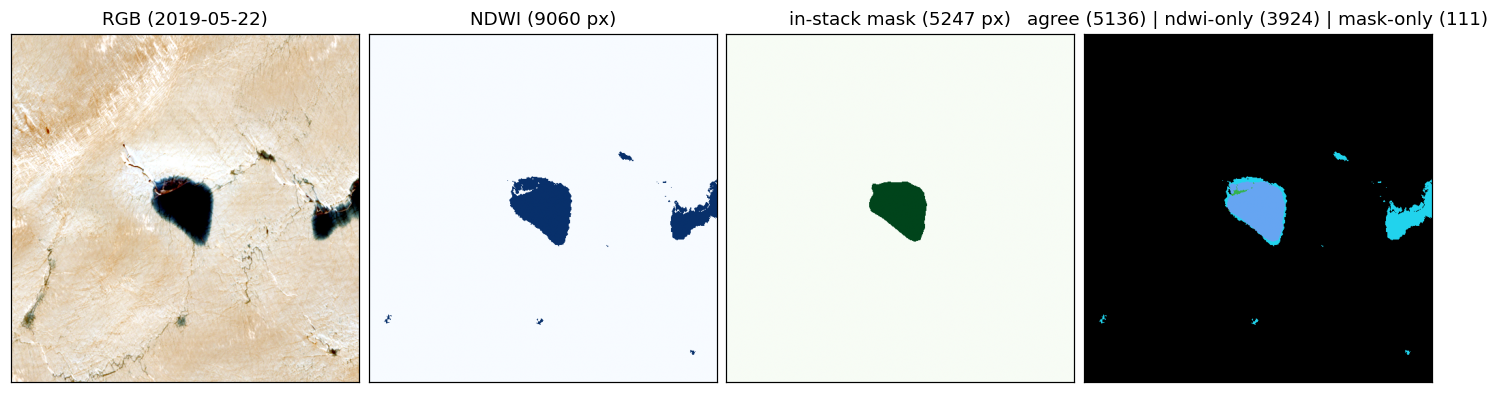

In [9]:
best = int(np.argmax(ndwi_per_day))
ndwi = (ndwi_cube[best] > 0).astype(np.uint8)
mask_band = ds_out.reflectance.isel(time=best, band=B_MASK).values
mask_b = (np.nan_to_num(mask_band, nan=0) > 0).astype(np.uint8)

agree   = ndwi & mask_b
ndwi_only = ndwi & (1 - mask_b)
mask_only = (1 - ndwi) & mask_b

rgb = np.stack([
    ds_out.reflectance.isel(time=best, band=B_RED).values,
    ds_out.reflectance.isel(time=best, band=B_GRN).values,
    ds_out.reflectance.isel(time=best, band=B_BLU).values,
], axis=-1)
rgb_s = stretch_rgb(rgb)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), constrained_layout=True)
axes[0].imshow(rgb_s);   axes[0].set_title(f'RGB ({str(ds_out.time.values[best].astype("datetime64[D]"))})')
axes[1].imshow(ndwi,      cmap='Blues',   vmin=0, vmax=1); axes[1].set_title(f'NDWI ({int(ndwi.sum())} px)')
axes[2].imshow(mask_b,    cmap='Greens',  vmin=0, vmax=1); axes[2].set_title(f'in-stack mask ({int(mask_b.sum())} px)')
rgb_diff = np.zeros((*ndwi.shape, 3))
rgb_diff[agree.astype(bool)]      = [0.40, 0.65, 0.95]
rgb_diff[ndwi_only.astype(bool)]  = [0.13, 0.83, 0.93]
rgb_diff[mask_only.astype(bool)]  = [0.20, 0.70, 0.30]
axes[3].imshow(rgb_diff); axes[3].set_title(f'agree ({int(agree.sum())}) | ndwi-only ({int(ndwi_only.sum())}) | mask-only ({int(mask_only.sum())})')
for a in axes:
    a.set_xticks([]); a.set_yticks([])
plt.show()

## What to check before scaling

- **Co-registration:** the cyan overlay in §3 should sit on top of obvious lake/water in the RGB, not next to it.
- **Bit-exact preservation:** §2 should print `True`. If it ever flips to `False` we have a regression.
- **Coverage:** the time series in §4 should peak in mid-season (typically late-June / July for CW Greenland).
- **Sanity vs in-stack mask:** §5's `agree` blob should clearly trace the lake. Pure `ndwi-only` or pure `mask-only` blobs covering a whole lake suggest bad alignment or wrong CRS.

Once a couple of representative lakes look right (one CD, one HF, one ND ideally), batch the rest on Sherlock as a SLURM array job.